# RAPID-MFA-1: The flow driven model

## Descriptions

This is the basic RAPID MFA flow driven model. It takes two inputs:
- An _inflows_ time series (of materials, products, service units, etc.) that become cohorts in the stocks.
- A _survival curve_ describing the survival/depreciation of inflow cohorts in the stocks as time goes by.

It produces two main model outputs:
- The _stocks_ time series
- The _outflows_ time series

And two auxiliary model outputs:
- The _cohorts survival matrix_ table
- The _stock changes_ (net addition to stock) time series

using the flow driven model equations:
$$
\begin{align}
\textcolor{#DC322F}{\text{stocks}(t)} &= \sum_{c=0}^{t}{ [ \textcolor{#2A8596}{\text{inflows}(c)} \times \textcolor{#722299}{\text{survival\_curve}(t-c)}  ] } 
\\
\textcolor{#8E795E}{\text{stock\_changes}(t)} &= \textcolor{#DC322F}{\text{stocks}(t)} - \textcolor{#DC322F}{\text{stocks}(t-1)} 
\\
\textcolor{#D19F37}{\text{outflows}(t)} &= \textcolor{#2A8596}{\text{inflows}(t)} - \textcolor{#8E795E}{\text{stock\_changes}(t)} 
\\
\end{align}
$$

### The exogenous input variables used in this example
__Inflows:__ mock inflow values for years 1950-2019, in kg/year.

__Survival curve:__ mock values. Normal distribution, $mean=30$, $SD=8.5$, chosen to exemplify that the model works even in a case in which survival in year 0 is not 100%, i.e. there is already some outflow (throughput) from each inflow in its year of occurance.

### Notes
1. The input data is intended to be replaced with your own data, for example imported from an Excel or CSV file. It should be in an array-like format of any length.
2. The model is split into separate code blocks for ease of understanding. The code blocks can be merged to run as a complete model.

### Relations with other RAPID-MFA notebooks
This code is the core building block for all other RAPID-MFA notebooks that use the flow driven model. Most don't modify this core code, except these two variants:

- `RAPID-MFA-2: The stock driven model`: the __survival curve__ is identical, and this code's _input_ __inflows__ data are identical to the model _output_ __inflows__ calculated in `RAPID-MFA-2: The stock driven model` to show that the flow-driven model and stock-driven model are the reverse operations of each other. The resulting MFA system of both codes has the same values (ignoring computational imprecision from roundoff errors).

- `RAPID-MFA-3: The flow driven model with outflow generation curves` replaces the _survival curve_ with the _outflow generation curve_ for use when the outflows composition is required. 

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 


## 1. Load libraries

In [21]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns

## 2. Define example input data

In [22]:
# %% 2. Define example input data

# inflows data
input_data = pd.Series([1300, 1400, 1200, 1000, 700, 2000, 2200, 2300, 2800, 3000, 
                        1400, 1300, 2000, 2200, 3000, 1500, 3000, 3300, 2800, 2900, 
                        1500, 2700, 3000, 3200, 3300, 3400, 3600, 3300, 3800, 3900, 
                        3300, 4000, 4400, 5000, 5100, 5200, 5400, 5800, 6200, 6000, 
                        6000, 6000, 6200, 7700, 6000, 5500, 5700, 5800, 5900, 6000, 
                        6200, 6600, 6400, 6500, 7000, 6500, 6600, 6700, 7000, 7700,
                        5800, 5900, 6000, 6000, 6200, 7700, 6000, 5500, 5700, 6700], 
                        name = 'inflows',
                        index = [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 
                                 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 
                                 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 
                                 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 
                                 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 
                                 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
                                 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])  # mock values

# Parameters for the survival curve
ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
mean = 30
std_dev = 8.5 

# create the survival curve
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev) 

## 3. Set up the MFA system

In [23]:
# %% 3. Set up the MFA system
units = {'time_interval': 'year', 
         'flows':         'kg/year', 
         'stocks':        'kg'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

time_interval = 1 # Interval between timeframes, often 1 year or 1 month etc.

cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required

mfa_system = pd.DataFrame(index = timeframes, columns = ['stocks',
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system['inflows'] = input_data
mfa_system['inflows']


1950    1300
1951    1400
1952    1200
1953    1000
1954     700
        ... 
2015    7700
2016    6000
2017    5500
2018    5700
2019    6700
Name: inflows, Length: 70, dtype: int64

## 4. Create the survival curves matrix

In this basic example, all inflow cohorts follow the same survival curve so the survival curve is shifted down the diagonal of the matrix, i.e. a [Toeplitz matrix](https://en.wikipedia.org/wiki/Toeplitz_matrix). check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for examples in which cohorts have differing survival curves, such as lifetime extension.

In [24]:
# %% 4. Create the survival curves matrix
# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]

survival_curves_matrix

,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
1950,0.999792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1951,0.999677,0.999792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1952,0.999506,0.999677,0.999792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1953,0.999255,0.999506,0.999677,0.999792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1954,0.998889,0.999255,0.999506,0.999677,0.999792,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015,0.000019,0.000032,0.000052,0.000083,0.000133,0.000208,0.000323,0.000494,0.000745,0.001111,...,0.998365,0.998889,0.999255,0.999506,0.999677,0.999792,0.000000,0.000000,0.000000,0.000000
2016,0.000011,0.000019,0.000032,0.000052,0.000083,0.000133,0.000208,0.000323,0.000494,0.000745,...,0.997625,0.998365,0.998889,0.999255,0.999506,0.999677,0.999792,0.000000,0.000000,0.000000
2017,0.000007,0.000011,0.000019,0.000032,0.000052,0.000083,0.000133,0.000208,0.000323,0.000494,...,0.996594,0.997625,0.998365,0.998889,0.999255,0.999506,0.999677,0.999792,0.000000,0.000000
2018,0.000004,0.000007,0.000011,0.000019,0.000032,0.000052,0.000083,0.000133,0.000208,0.000323,...,0.995177,0.996594,0.997625,0.998365,0.998889,0.999255,0.999506,0.999677,0.999792,0.000000


## 5. Create cohorts survival matrix

Each column of the cohorts' survival matrix describes the decline of an inflow cohort as time goes by.

Each row of the cohorts' survival matrix describes the amount still in the stock of each past and present inflow cohort, i.e. the composition of the stocks.

[Text(0.5, 23.52222222222222, "Cohorts (each inflow's own survival)"),
 Text(50.722222222222214, 0.5, 'Timeframe (how much of each inflow is still in stock)')]

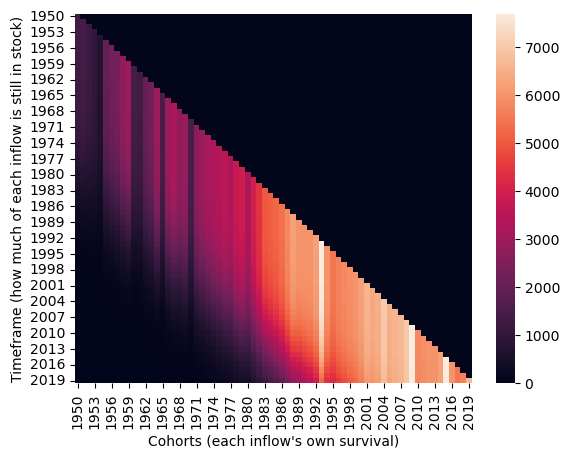

In [25]:
# %% 5. Create cohorts survival matrix

# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # scale the shifted survival curve with the inflow of the time-th timeframe
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system['inflows'].loc[cohort]

# and visualize the cohort_survival_matrix matrix with a heatmap
sns.heatmap(cohorts_survival_matrix, annot=False).set(xlabel ="Cohorts (each inflow's own survival)", ylabel = "Timeframe (how much of each inflow is still in stock)")

## 6. Calculate the MFA system
### 6.1 Calculate stocks

$$
\begin{align}
\textcolor{#DC322F}{\text{stocks}(t)} &= \sum_{c=0}^{t}{ [ \textcolor{#2A8596}{\text{inflows}(c)} \times \textcolor{#722299}{\text{survival\_curve}(t-c)}  ] } \\
&= \sum_{c=0}^{t}{\text{surviving\_cohorts}(c)}
\end{align}
$$

In [26]:
# %% 6. Calculate the MFA system
# %%% 6.1 Calculate stocks 
# the stocks are the sum of the surviving cohorts, which is the sum of cohorts survival matrix row by row.
mfa_system["stocks"] = cohorts_survival_matrix.sum(axis='columns')
mfa_system["stocks"]

1950      1299.729285
1951      2699.288926
1952      3898.656550
1953      4897.744364
1954      5596.451220
            ...      
2015    185330.266140
2016    186321.999811
2017    186683.591985
2018    187120.854914
2019    188440.232031
Name: stocks, Length: 70, dtype: float64

### 6.2 Calculate stock changes
$$\textcolor{#8E795E}{\text{stock\_changes}(t)} = \textcolor{#DC322F}{\text{stocks}(t)} - \textcolor{#DC322F}{\text{stocks}(t-1)}$$
prepend=0 replicates the convention that stock_change is the difference between current timeframe and previous timeframe. 

In [27]:
# %%% 6.2 calculate stock changes (net change to stock)
# stock_changes is the difference between two timeframes.
# prepend=0 replicates the convention that stock_change is the difference between current timeframe and previous timeframe. 
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["stock_changes"]

1950    1299.729285
1951    1399.559641
1952    1199.367624
1953     999.087814
1954     698.706856
           ...     
2015    2826.792258
2016     991.733671
2017     361.592175
2018     437.262928
2019    1319.377117
Name: stock_changes, Length: 70, dtype: float64

### 6.3 Calculate outflows
using mass balance
$$\textcolor{#D19F37}{\text{outflows}(t)} = \textcolor{#2A8596}{\text{inflows}(t)} - \textcolor{#8E795E}{\text{stock\_changes}(t)}$$

In [28]:
# %%% 6.3 Calculate outflows
# using mass balance
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]
mfa_system["outflows"]

1950       0.270715
1951       0.440359
1952       0.632376
1953       0.912186
1954       1.293144
           ...     
2015    4873.207742
2016    5008.266329
2017    5138.407825
2018    5262.737072
2019    5380.622883
Name: outflows, Length: 70, dtype: float64

## 7. View the full MFA system

<Axes: ylabel='kg/year'>

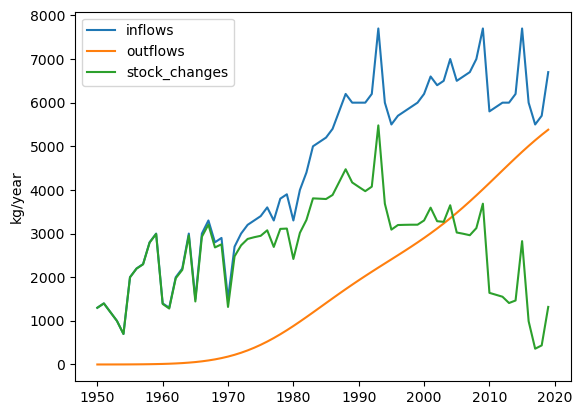

In [29]:
# %% 7. View the full MFA system
# plot flows
mfa_system[["inflows", "outflows", "stock_changes"]].plot(ylabel=units['flows'])

<Axes: ylabel='kg'>

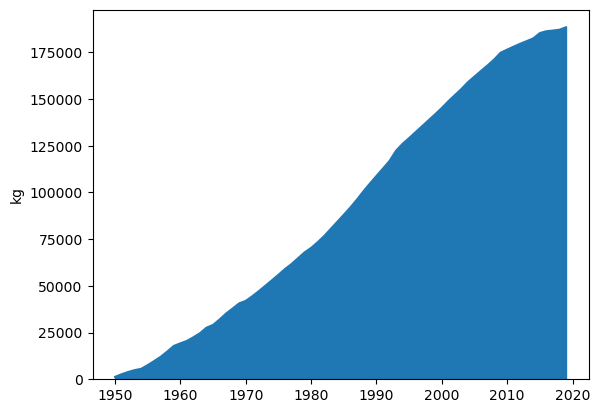

In [30]:
# plot stocks
mfa_system["stocks"].plot(kind="area", stacked=True, ylabel=units['stocks'])

<Axes: ylabel='kg'>

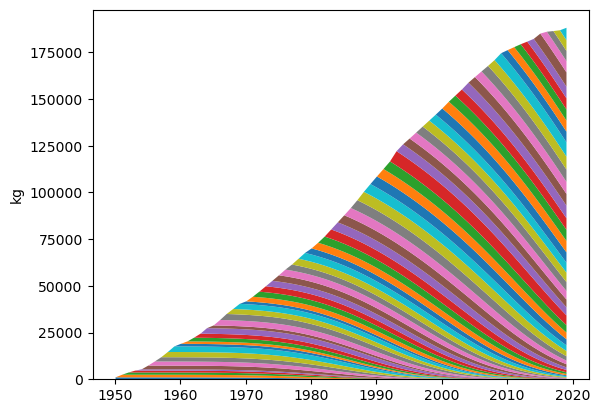

In [31]:
# plot stocks composition by cohorts
cohorts_survival_matrix.plot(kind="area", stacked=True, legend = False, lw=0, ylabel=units['stocks'])